# Лабораторная работа №1
# "Прогнозирование стоимости квартир в городе N"

ЦЕЛЬ РАБОТЫ - предсказать стоимость квартир в городе N

РЕШАЕМАЯ ЗАДАЧА - подобрать и обучить модель МО способную предсказать стоимость квартир на основе имеющихся (данных) признаков

ХОД РАБОТЫ

1) Загрузка и изучение данных
2) Предобработка данных
3) Исследовательский анализ данных
4) Добавление новых признаков, обоснование выбора
5) Корреляционный анализ признаков 
6) Решение задачи регресии
7) Итоговые выводы

ОПИСАНИЕ ДАННЫХ

Данные таблицы data_lab_1.csv содержат следующую информацию:

- price - цена квартиры (целевой признак)
- total_area - площадь квартиры 
- rooms - количество комнат 
- ceiling_height - высота потолков 
- floors_total - количество этажей в доме
- living_area - жилая площадь квартиры
- floor - этаж 
- studio - является ли квартира студией 
- kitchen_area - площадь кухни
- balcony - наличие балкона или балконов 
- airports_distance - расстояние до аэропорта 
- centers_distance - расстояние до центра города 
- parks_nearest - расстояние для ближайшего парка 
- ponds_nearest - расстояние до ближайшего водоема

## Импорт необходимых пакетов

<div class="alert alert-info">
<b>Перед началом работы над проектом установим и импортируем все необходимые пакеты</b>
<br>
</div>

In [1]:
# """!pip install phik"""

In [2]:
# """!pip uninstall setuptools"""

In [3]:
# """!pip install setuptools==66.1.1"""

In [4]:
# pip install lightgbm

In [5]:
# pip install --upgrade scikit-learn -q

In [6]:
# pip install shap

In [7]:
pip list

Package                   Version
------------------------- --------------
anyio                     4.10.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.5
attrs                     25.3.0
babel                     2.17.0
beautifulsoup4            4.9.3
bleach                    6.2.0
Brotli                    1.1.0
cached-property           1.5.2
certifi                   2025.8.3
cffi                      1.17.1
charset-normalizer        3.4.3
click                     8.1.8
cloudpickle               3.1.1
colorama                  0.4.6
comm                      0.2.3
cycler                    0.12.1
debugpy                   1.8.16
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.0
executing                 2.2.0
fastjsonschema            2.21.2
fqdn                      1.5.1
greenlet                  3.2.4
h11              

In [8]:
import pandas as pd
import numpy as np
import phik
import math
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import binom, poisson
import shap

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

from scipy.spatial.distance import cosine
from scipy.spatial.distance import euclidean

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import recall_score, precision_score, accuracy_score
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import confusion_matrix

from phik import phik_matrix
from phik.report import plot_correlation_matrix

RANDOM_STATE = 42
TEST_SIZE = 0.25
warnings.filterwarnings('ignore')

## Шаг 1. Загрузка данных

<div class="alert alert-info">
<b>Выгрузим и изучим данные из таблицы data_lab_1.csv </b>
<br>
</div>

In [9]:
data = pd.read_csv('data_lab_1.csv')

In [10]:
def check_data(name_csv):
    print('Общая информация **************************************************************************************************************************')
    print(name_csv.info())
    print('Первые пять строк *************************************************************************************************************************')
    print(name_csv.head())
    print('Название столбцов *************************************************************************************************************************')
    print(name_csv.columns)
    print('Число пропущенных значений  ***************************************************************************************************************')
    print(name_csv.isna().sum())
    print('Число ЯВНЫХ дубликатов ********************************************************************************************************************')
    print(name_csv.duplicated().sum())
    display(name_csv.describe().T)
    name_csv.hist(figsize=(15, 20))
    display(data)

Общая информация **************************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              23699 non-null  float64
 1   total_area         23699 non-null  float64
 2   rooms              23699 non-null  int64  
 3   ceiling_height     14504 non-null  float64
 4   floors_total       23613 non-null  float64
 5   living_area        21796 non-null  float64
 6   floor              23699 non-null  int64  
 7   studio             23699 non-null  bool   
 8   kitchen_area       21421 non-null  float64
 9   balcony            12180 non-null  float64
 10  airports_distance  18157 non-null  float64
 11  centers_distance   18180 non-null  float64
 12  parks_nearest      8079 non-null   float64
 13  ponds_nearest      9110 no

,count,mean,std,min,25%,50%,75%,max
price,23699.0,6.541549e+06,1.088701e+07,12190.0,3400000.00,4650000.00,6800000.0,763000000.0
total_area,23699.0,6.034865e+01,3.565408e+01,12.0,40.00,52.00,69.9,900.0
rooms,23699.0,2.070636e+00,1.078405e+00,0.0,1.00,2.00,3.0,19.0
ceiling_height,14504.0,2.771499e+00,1.261056e+00,1.0,2.52,2.65,2.8,100.0
floors_total,23613.0,1.067382e+01,6.597173e+00,1.0,5.00,9.00,16.0,60.0
living_area,21796.0,3.445785e+01,2.203045e+01,2.0,18.60,30.00,42.3,409.7
floor,23699.0,5.892358e+00,4.885249e+00,1.0,2.00,4.00,8.0,33.0
kitchen_area,21421.0,1.056981e+01,5.905438e+00,1.3,7.00,9.10,12.0,112.0
balcony,12180.0,1.150082e+00,1.071300e+00,0.0,0.00,1.00,2.0,5.0
airports_distance,18157.0,2.879367e+04,1.263088e+04,0.0,18585.00,26726.00,37273.0,84869.0


,price,total_area,rooms,ceiling_height,floors_total,living_area,floor,studio,kitchen_area,balcony,airports_distance,centers_distance,parks_nearest,ponds_nearest
0,13000000.0,108.00,3,2.70,16.0,51.0,8,False,25.00,NaN,18863.0,16028.0,482.0,755.0
1,3350000.0,40.40,1,NaN,11.0,18.6,1,False,11.00,2.0,12817.0,18603.0,NaN,NaN
2,5196000.0,56.00,2,NaN,5.0,34.3,4,False,8.30,0.0,21741.0,13933.0,90.0,574.0
3,64900000.0,159.00,3,NaN,14.0,NaN,9,False,NaN,0.0,28098.0,6800.0,84.0,234.0
4,10000000.0,100.00,2,3.03,14.0,32.0,13,False,41.00,NaN,31856.0,8098.0,112.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9700000.0,133.81,3,3.70,5.0,73.3,3,False,13.83,NaN,24665.0,4232.0,796.0,381.0
23695,3100000.0,59.00,3,NaN,5.0,38.0,4,False,8.50,NaN,NaN,NaN,NaN,NaN
23696,2500000.0,56.70,2,NaN,3.0,29.7,1,False,NaN,NaN,NaN,NaN,NaN,NaN
23697,11475000.0,76.75,2,3.00,17.0,NaN,12,False,23.30,2.0,39140.0,10364.0,173.0,196.0


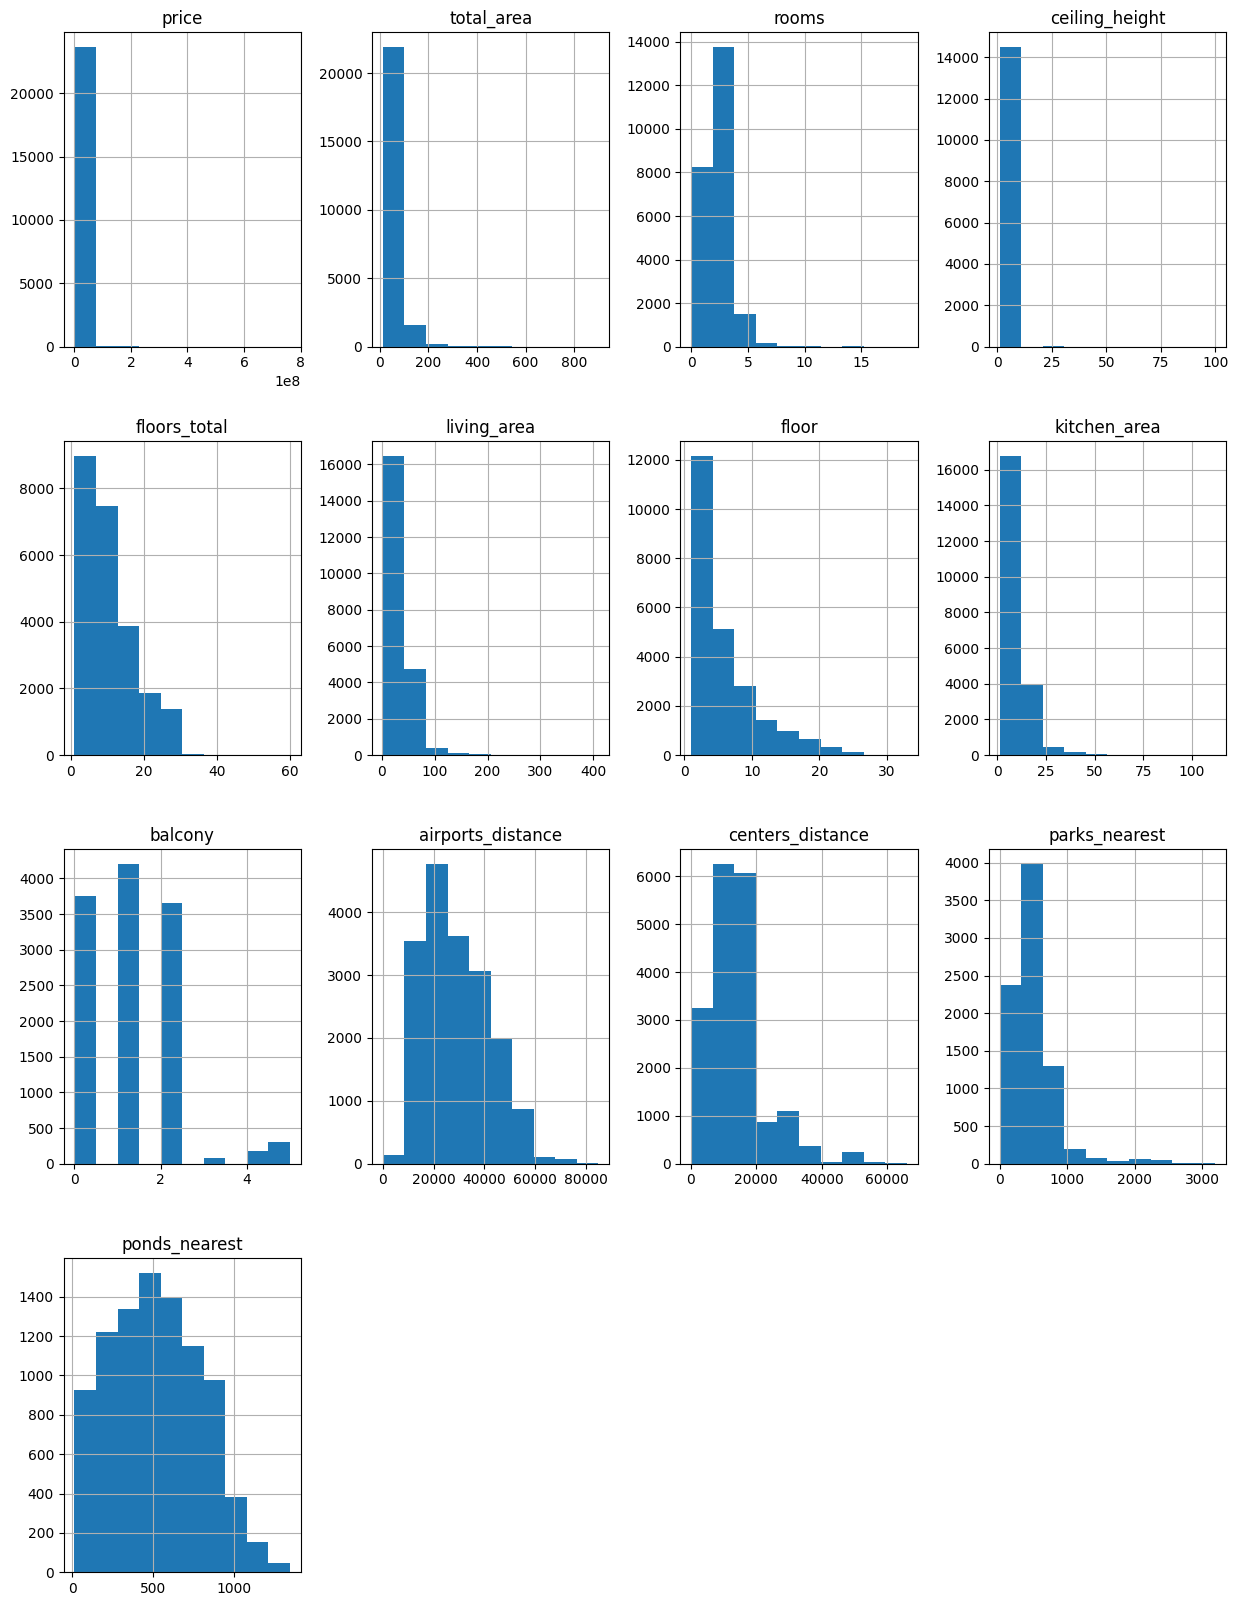

In [11]:
check_data(data)

<div class="alert alert-info">
<b>
Вывод к Шагу 1: Первое впечатление о данных следующее))
    
1) В данных есть пропуски и их довольно много (в 8 столбцах)
2) По гистограммам видно, что в данных есть выбросы и/или аномалии
3) ЯВНЫХ дубликатов только 1 
4) Некоторые типы данных нужно поменять, например, такие как floors_total, ведь очевидно что количество этажей в доме - это целое число
5) Название столбцов читаемо и легко интерпретируется </b>
<br>
</div>

## Шаг 2. Предобработка данных

<div class="alert alert-info">
<b> Для начала исправим тип данных в следующих столбцах и заодно разберемся с пропусками:
    
ТИП ДАННЫХ
- floors_total - так как число этажей это целое число --> преобразуем в int
- balcony - число балконов это целочисленный тип данных --> преобразуем в int

ПРОПУСКИ
- floors_total - Логично будет предположить, что если не указано количество количество этажей, то значит что дом - одноэтажный, значит все пропуски заменяем на "1"(а вообще количество пропусков в данном столбце незначительное можно и удалить или проигнорировать)
- balcony - если есть пропуск, то скорее всего это значит, что балконов в квартире - НЕТ, меняем пропуски на "0"</b>
<br>
</div>

In [12]:
data['floors_total'] = data['floors_total'].fillna(1).astype(int)
data['balcony'] = data['balcony'].fillna(0).astype(int)

<div class="alert alert-info">
<b> Для начала исправим тип данных в следующих столбцах и заодно разберемся с пропусками:
    
Далее посмотрим что в столбце ceiling_height тоже довольно много пропусков - оптимальное решение - заменить на медианное значение, 
так как город один и думается мне что в одной локации примерно один и тот же диапазон высоты потолков 

Для столбцов living_area / kithen_area можно найти соотношение средней жилой / кухонной площади к средней общей площади и использовать полученное значение для замены пропусков

Следующие столбцы ... ---> 

airports_distance - расстояние до аэропорта

centers_distance - расстояние до центра города 

parks_nearest - расстояние для ближайшего парка 

ponds_nearest - расстояние до ближайшего водоема

---> ... Это какой то милый сюрприз, потому что я не знаю что с ними делать, могу предположить, что тем кто заполнял эту таблицу было лень считать все эти значения, или если это автозаполняемые данные - то возникла какая то ошибка в работе алгоритма или пользователь просто неправильно ввел данные или адрес квартиры и алгоритм не смог посчитать. Причин может быть много, я бы оставила эти столбцы без изменений, так как процент пропусков в каждом из признаков очень большой и если ошибочно удалить или заменить данные то для обучаемой  модели это может навредить. Я НЕ БУДУ УБИРАТЬ ПРОПУСКИ В ДДАННЫХ ПОСЛЕДНИХ ЧЕТЫРЕХ ПРИЗНАКАХ ТАК КАК ВЫБЕРУ МОДЕЛЬ КОТОРАЯ УМЕЕТ РАБОТАТЬ С ПРОПУСКАМИ В ДАННЫХ

<br>
</div>

In [13]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())
data['living_area'] = data['living_area'].fillna(data['living_area'].mean()/data['total_area'].mean())
data['kitchen_area'] = data['kitchen_area'].fillna(data['kitchen_area'].mean()/data['total_area'].mean())

<div class="alert alert-info">
<b> Посмотрим заново на пропуски)
<br>
</div>

In [14]:
data.isna().sum()

price                    0
total_area               0
rooms                    0
ceiling_height           0
floors_total             0
living_area              0
floor                    0
studio                   0
kitchen_area             0
balcony                  0
airports_distance     5542
centers_distance      5519
parks_nearest        15620
ponds_nearest        14589
dtype: int64

<div class="alert alert-info">
<b> Прекрасно, считаю все что могли заменить - заменили, теперь можно занятся явными дубликатами, НО ИХ НЕТ!!! и неявных тоже) поэтому перейдем к выбросам и аномалиям (в шаге 3)) 
<br>
</div>

In [15]:
data = data.drop_duplicates().reset_index(drop=True)

In [16]:
data.duplicated().sum()

0

<div class="alert alert-info">
<b>
Вывод к Шагу 2: В ходе предобработки данных было выполнено следующее -->
    
1) Преобразованы типы данных
2) Убраны пропуски (там где это возможно)

</div>

## Шаг 3. Исследовательский анализ данных

<div class="alert alert-info">
<b> Для начала, проведем статистический анализ признаков) для этого напишем функцию которая строит гистограмму, "ящик с усами" и кругову. диаграмму)
<br>
</div>

In [17]:
def hist(column):
    print(data[column].describe())
    plt.hist(data[column])
    plt.title(f'Распределение признака {column}')
    plt.xlabel(column)
    plt.ylabel("Количество квартир")
    plt.show()
def bxplt(column):
    sns.boxplot(data = data, y = column)
    plt.title('Ящик с усами')
    plt.ylabel(column)
def pie(column):
    print(data[column].value_counts())
    fig, ax = plt.subplots()
    ax.pie(data[column].value_counts(), labels=data[column].unique(), autopct='%.2f%%')
    plt.title(f'Распределение признака {column}')

<div class="alert alert-warning">
<b> Признак "price" - цена квартиры </b> 
<br>
</div>

count    2.369800e+04
mean     6.541718e+06
std      1.088721e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: price, dtype: float64


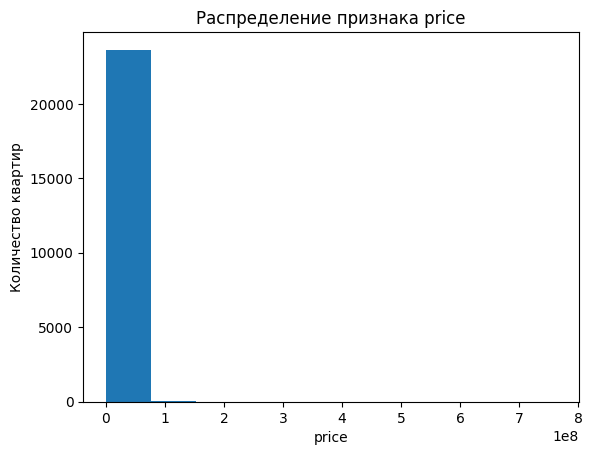

In [18]:
hist('price')

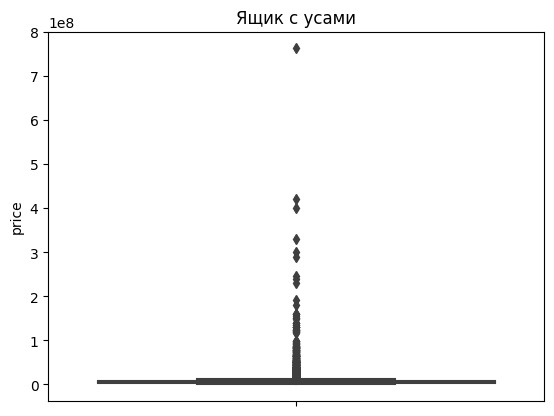

In [19]:
bxplt('price')

<div class="alert alert-info">
<b> Я убираю все квартиры меньше 500000 и больше 20 000 000, так как квартир с такими ценами чуть больше 3%)
<br>
</div>

In [20]:
print(f'Процент выбросов в признаке "price": {(len(data.query("price > 20000000 | price < 500000")) / len(data) * 100)}%')

Процент выбросов в признаке "price": 3.0424508397333105%


In [21]:
data = data.query("500000 < price < 20000000")

count    2.295700e+04
mean     5.417479e+06
std      3.196450e+06
min      5.200000e+05
25%      3.400000e+06
50%      4.550000e+06
75%      6.500000e+06
max      1.999900e+07
Name: price, dtype: float64


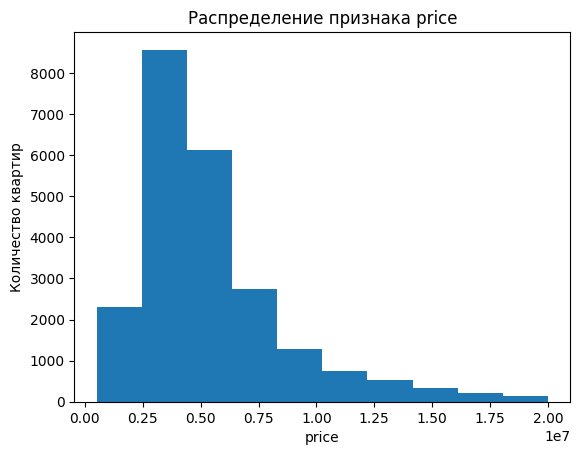

In [22]:
hist('price')

<div class="alert alert-info">
<b> Теперь распределение выглядит более менее адекватно и с ним можно работать дальше)
<br>
</div>

<div class="alert alert-warning">
<b> Признак 'total_area' - площадь квартиры </b> 
<br>
</div>

count    22957.000000
mean        56.689735
std         24.613049
min         12.000000
25%         40.000000
50%         51.000000
75%         67.100000
max        320.000000
Name: total_area, dtype: float64


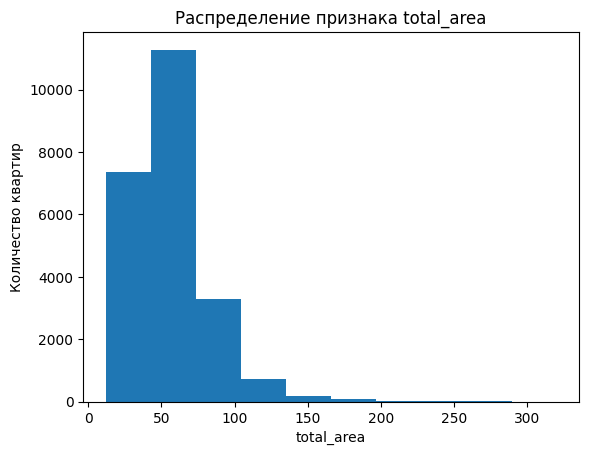

In [23]:
hist('total_area')

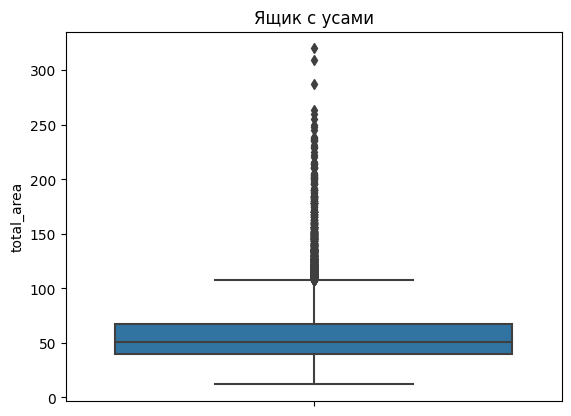

In [24]:
bxplt('total_area')

<div class="alert alert-info">
<b> Посмотрим на процент выбросов в признаке)
<br>
</div>

In [25]:
print(f'Процент выбросов в признаке "total_area": {(len(data[data["total_area"] > 110]) / len(data) * 100)}%')

Процент выбросов в признаке "total_area": 3.40201245807379%


<div class="alert alert-info">
<b> Выбросы не стану удалять так как они могут быть обусловлены тем, что речь в данном случае идет о пентхаусах, которые могут достигать 300-400 м^2
<br>
</div>

<div class="alert alert-warning">
<b> Признак 'rooms' - количество комнат  </b> 
<br>
</div>

count    22957.000000
mean         2.009888
std          0.985139
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: rooms, dtype: float64


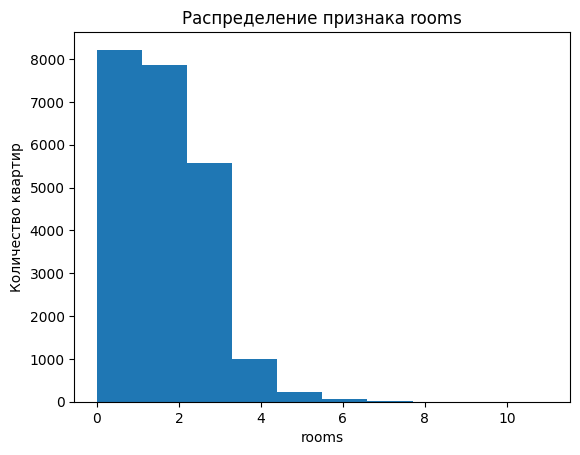

In [26]:
hist('rooms')

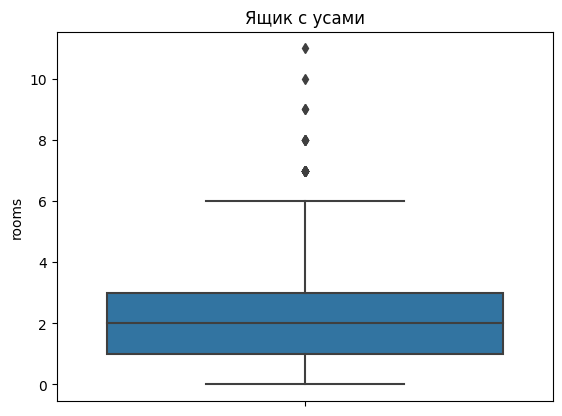

In [27]:
bxplt('rooms')

In [28]:
print(f'Процент выбросов в признаке "rooms": {(len(data.query("rooms > 6 | rooms < 1")) / len(data) * 100)}%')

Процент выбросов в признаке "rooms": 0.9844491876116218%


<div class="alert alert-info">
<b> Выбросов малое каличество(чуть меньше 1 процента)), можно оставить как есть)
<br>
</div>

<div class="alert alert-warning">
<b> 'ceiling_height' - высота потолков   </b> 
<br>
</div>

count    22957.000000
mean         2.714745
std          0.999582
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64


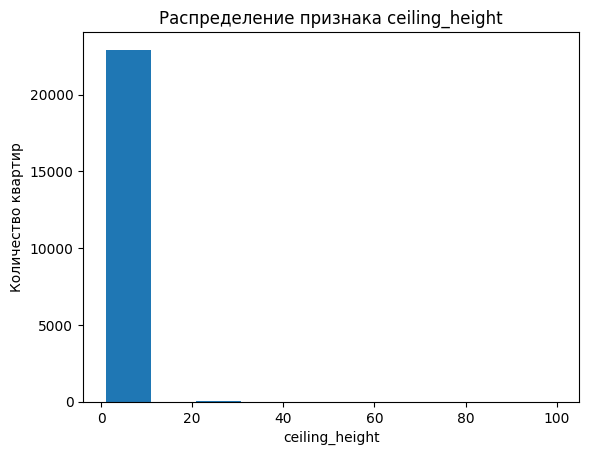

In [29]:
hist('ceiling_height')

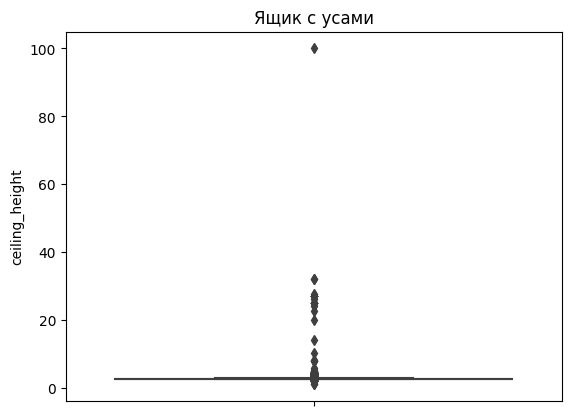

In [30]:
bxplt('ceiling_height') 

<div class="alert alert-info">
<b> невозможная высота потолка 100м, если это не дворец или что то подобное, поэтому позволю себе удалить данное значение признака)
<br>
</div>

In [31]:
data = data.query('ceiling_height < 100')

count    22956.000000
mean         2.710507
std          0.766085
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max         32.000000
Name: ceiling_height, dtype: float64


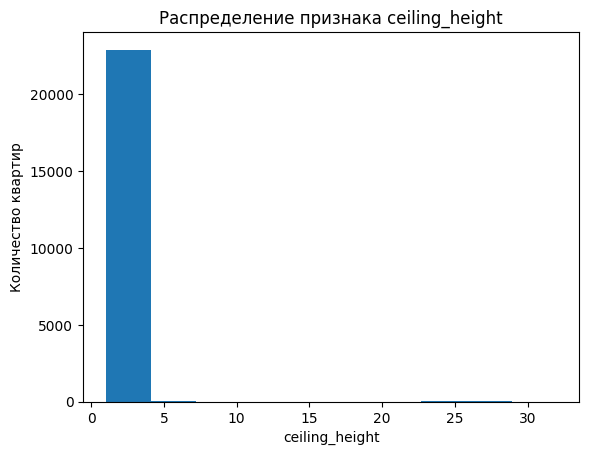

In [32]:
hist('ceiling_height')

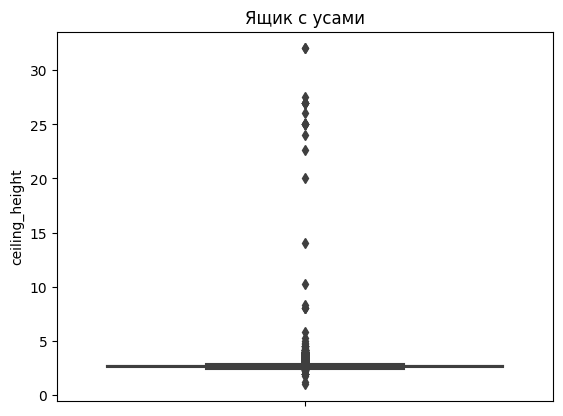

In [33]:
bxplt('ceiling_height') 

<div class="alert alert-info">
<b> выбросов много, посчитаем их процент
    
УЧТЕМ ЧТО Минимальная высота потолков для жилых помещений в России составляет 2,5 метра, однако в холодных регионах, таких как Санкт-Петербург, минимальный норматив может увеличиваться до 2,7 метра. В коридорах и холлах допустима высота в 2,1 метра. 

Максимальный размер потолков в квартире нормативно не ограничен, но на практике он зависит от класса здания и типа жилья: в стандартных новостройках высота обычно составляет 2,6–3,2 м, а в элитных комплексах и старых домах (например, "сталинках") потолки могут достигать 3,5–4 м и выше, включая редкие лоты площадью 5–6 м в пентхаусах и двухуровневых квартирах. 
<br>
</div>

In [34]:
print(f'Процент выбросов в признаке "ceiling_height": {(len(data.query("ceiling_height < 2.5 | ceiling_height > 6")) / len(data) * 100)}%')

Процент выбросов в признаке "ceiling_height": 0.439972120578498%


<div class="alert alert-info">
<b> Удалю выбросы так как диапазон у них на мой взгляд большой и это может повлиять на модель)
<br>
</div>

In [35]:
data = data.query("2.5 <= ceiling_height <= 6")

count    22855.000000
mean         2.687471
std          0.201140
min          2.500000
25%          2.600000
50%          2.650000
75%          2.700000
max          5.800000
Name: ceiling_height, dtype: float64


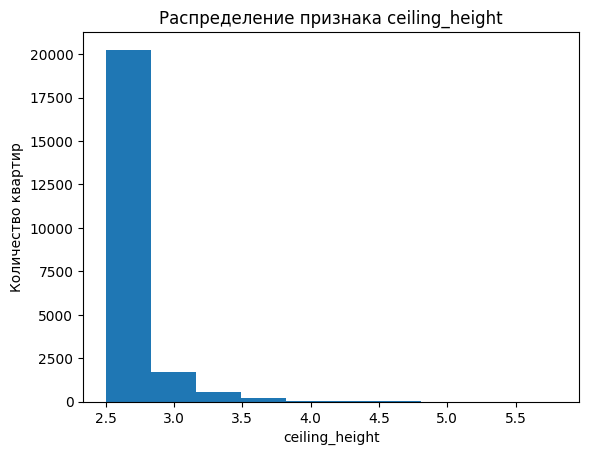

In [36]:
hist('ceiling_height') 

<div class="alert alert-warning">
<b> Признак floors_total - количество этажей в доме </b> 
<br>
</div>

count    22855.000000
mean        10.719974
std          6.645909
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64


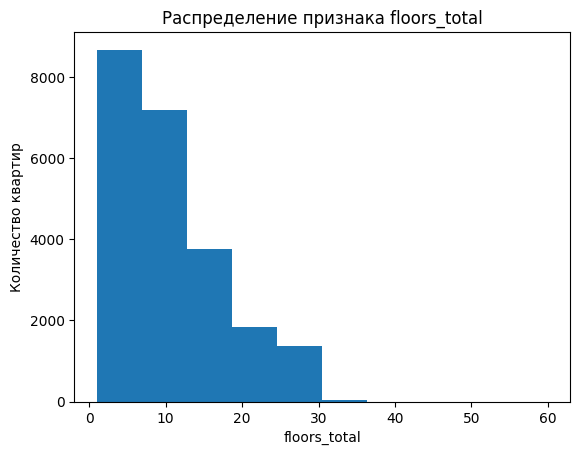

In [37]:
hist('floors_total')

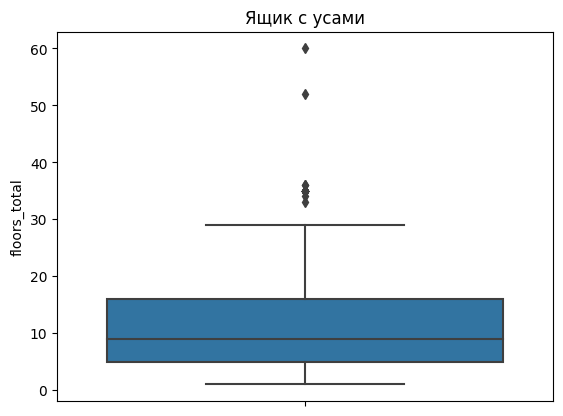

In [38]:
bxplt('floors_total')

<div class="alert alert-info">
<b> Аналогично с другими признаками посчитаем процент выбросов)
<br>
</div>

In [39]:
print(f'Процент выбросов в признаке "floors_total": {(len(data[data["floors_total"] > 30]) / len(data) * 100)}%')

Процент выбросов в признаке "floors_total": 0.13126230584117263%


In [40]:
data = data.query("floors_total <= 30")

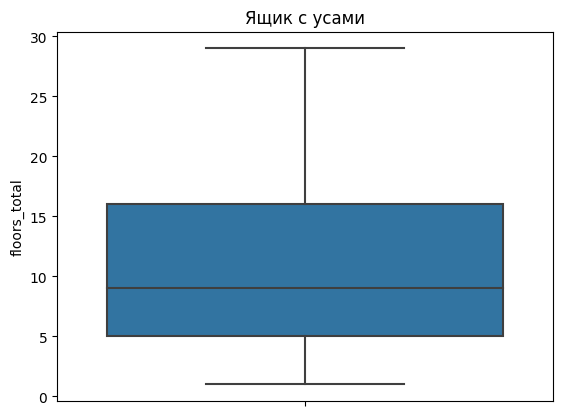

In [41]:
bxplt('floors_total')

<div class="alert alert-warning">
<b> Признак living_area - жилая площадь квартиры </b> 
<br>
</div>

<div class="alert alert-info">
<b> Аналогично
<br>
</div>

count    22825.000000
mean        30.037023
std         18.199261
min          0.570980
25%         17.700000
50%         28.900000
75%         40.000000
max        199.000000
Name: living_area, dtype: float64


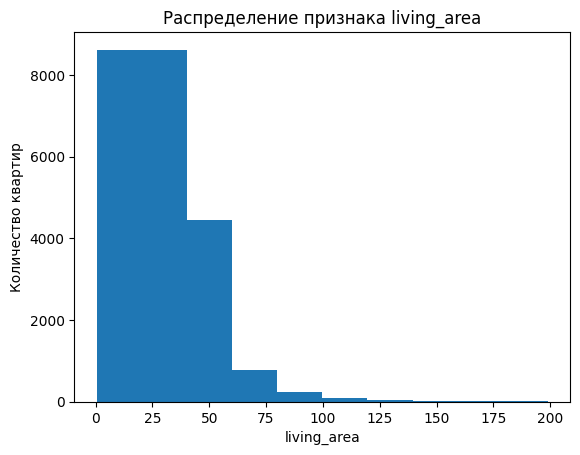

In [42]:
hist('living_area')

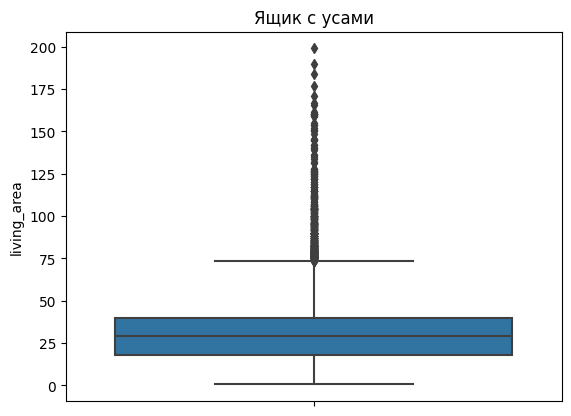

In [43]:
bxplt('living_area')

<div class="alert alert-info">
<b> На мой взгляд с этим признаком все хорошо, большие площади могут быть обусловлены тем, что под ними подразумевается пентхаус 
<br>
</div>

<div class="alert alert-warning">
<b> Признак floor - этаж  </b> 
<br>
</div>

count    22825.000000
mean         5.887755
std          4.877820
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         27.000000
Name: floor, dtype: float64


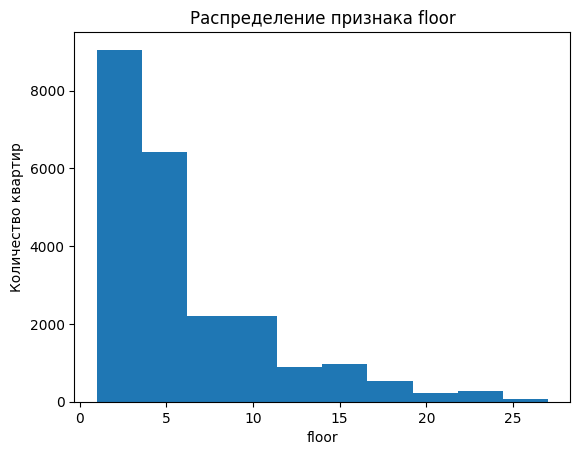

In [44]:
hist('floor')

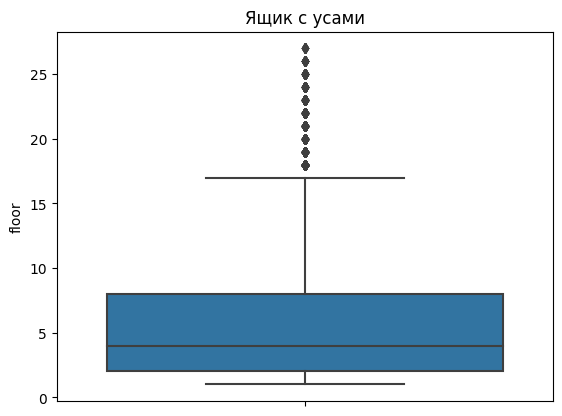

In [45]:
bxplt('floor')

<div class="alert alert-info">
<b> Этот признак тоже не трогаем)
<br>
</div>

<div class="alert alert-warning">
<b> Признак studio - является ли квартира студией  </b> 
<br>
</div>

False    22677
True       148
Name: studio, dtype: int64


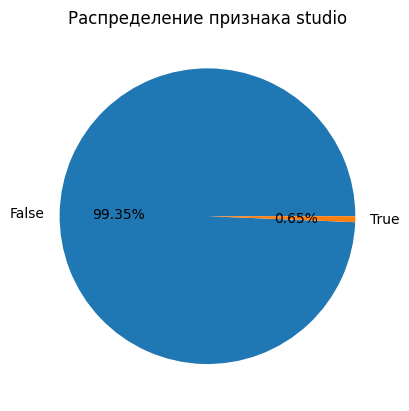

In [46]:
pie('studio')

<div class="alert alert-info">
<b> Ну по этой диаграмме видно, что в выборке почти нет квартир студий)
<br>
</div>

<div class="alert alert-warning">
<b> Признак kitchen_area - площадь кухни  </b> 
<br>
</div>

count    22825.000000
mean         9.170446
std          5.354822
min          0.175146
25%          6.300000
50%          8.700000
75%         11.000000
max        100.700000
Name: kitchen_area, dtype: float64


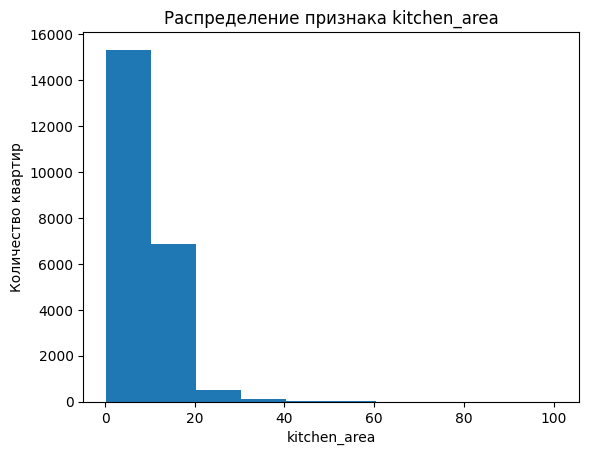

In [47]:
hist('kitchen_area')

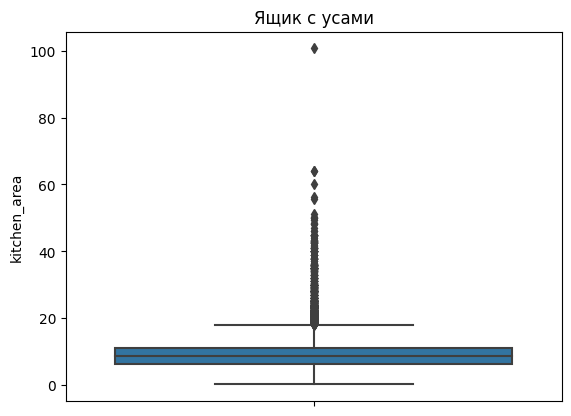

In [48]:
bxplt('kitchen_area')

<div class="alert alert-info">
<b> Ну разные площади у квартир значит разные площади и у кухонь, оставляем все как есть не вижу проблем
<br>
</div>

<div class="alert alert-warning">
<b> Признак balcony - наличие балкона или балконов  </b> 
<br>
</div>

count    22825.000000
mean         0.591457
std          0.953974
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: balcony, dtype: float64


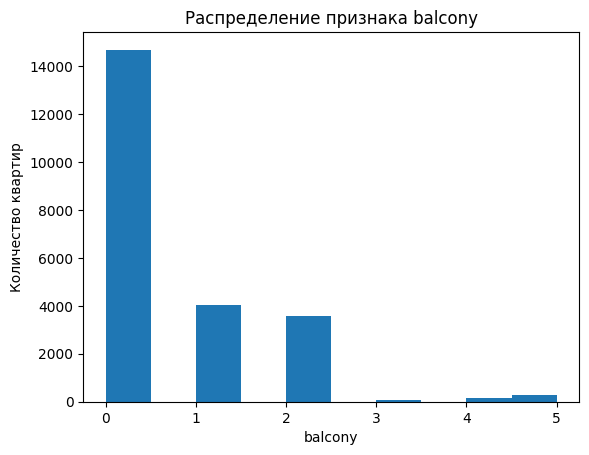

In [49]:
hist('balcony')

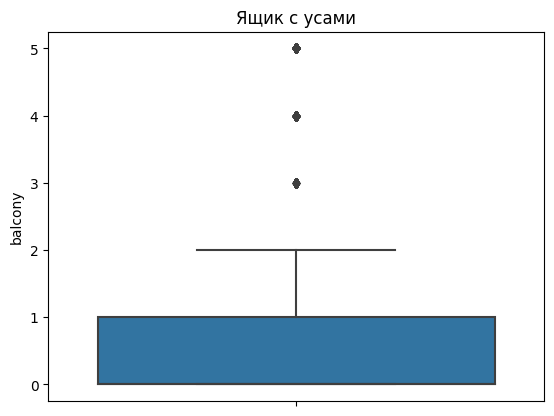

In [50]:
bxplt('balcony')

<div class="alert alert-info">
<b> Тоже все хорошо, СТОИТ ОТМЕТИТЬ ЧТО => спектр значений дискретный, признак может принимать только определенные значения
<br>
</div>

<div class="alert alert-warning">
<b> Признак airports_distance - расстояние до аэропорта  </b> 
<br>
</div>

count    17364.000000
mean     28873.291695
std      12793.951211
min          0.000000
25%      18416.250000
50%      26880.500000
75%      37434.000000
max      84869.000000
Name: airports_distance, dtype: float64


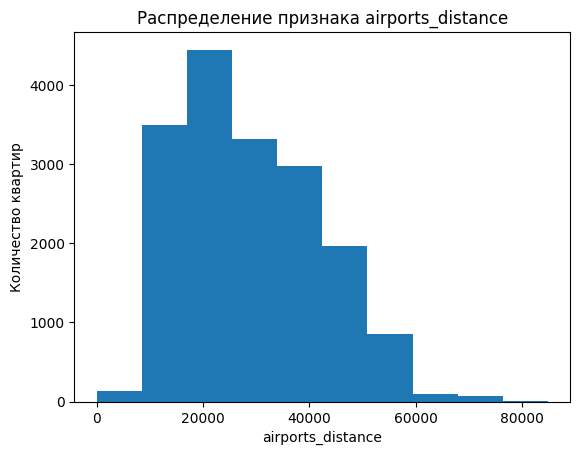

In [51]:
hist('airports_distance')

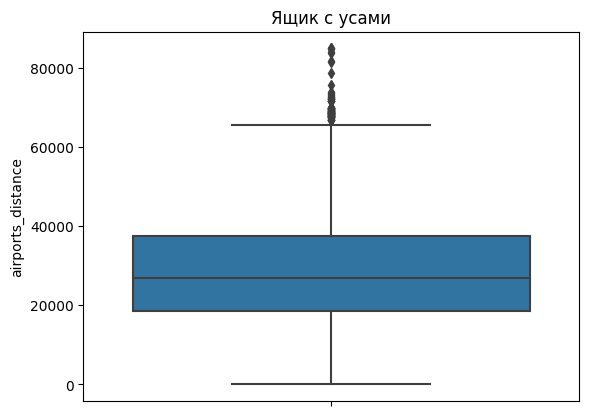

In [52]:
bxplt('airports_distance')

<div class="alert alert-warning">
<b> Признак centers_distance - расстояние до центра города   </b> 
<br>
</div>

count    17381.000000
mean     14488.594442
std       8574.509658
min        208.000000
25%       9816.000000
50%      13271.000000
75%      16453.000000
max      65968.000000
Name: centers_distance, dtype: float64


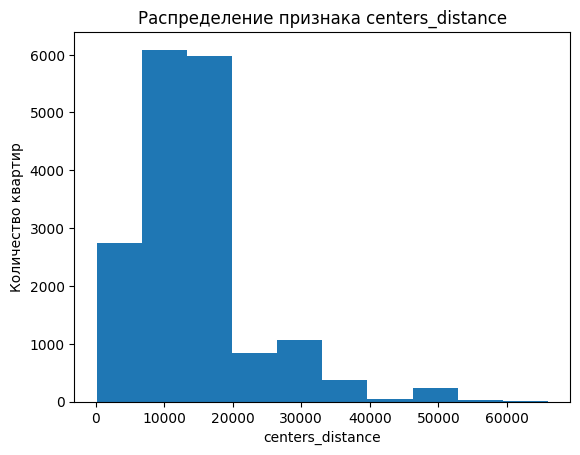

In [53]:
hist('centers_distance')

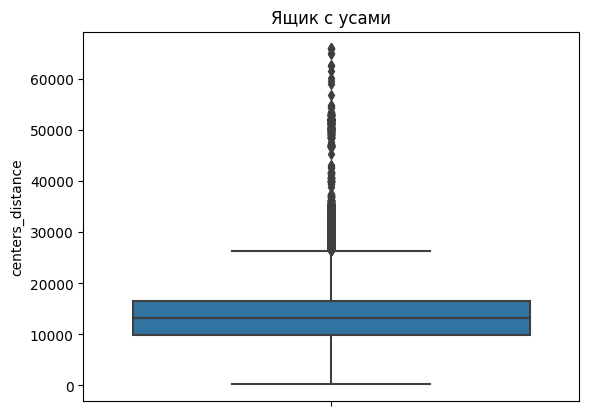

In [54]:
bxplt('centers_distance')

<div class="alert alert-warning">
<b> Признак parks_nearest - расстояние для ближайшего парка   </b> 
<br>
</div>

count    7520.000000
mean      493.968484
std       342.657394
min         1.000000
25%       289.000000
50%       456.000000
75%       614.000000
max      3190.000000
Name: parks_nearest, dtype: float64


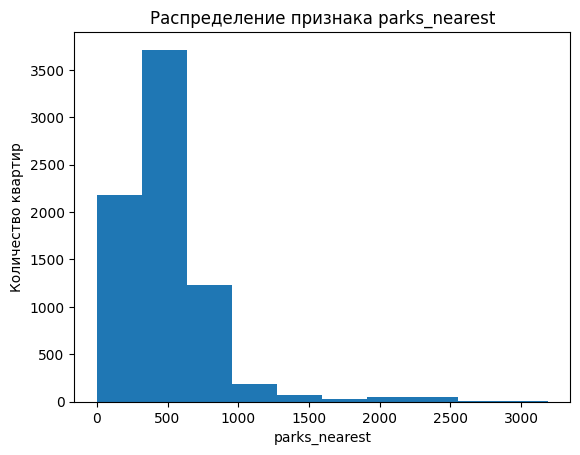

In [55]:
hist('parks_nearest')

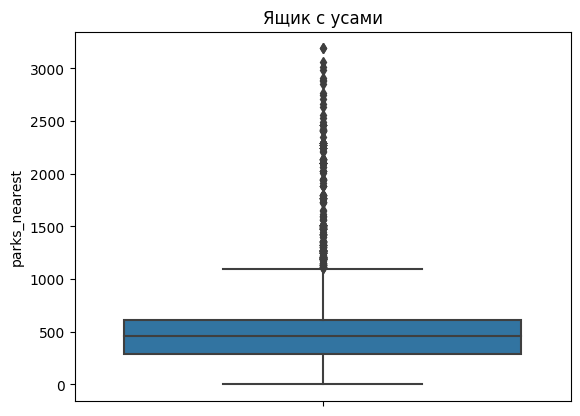

In [56]:
bxplt('parks_nearest')

<div class="alert alert-warning">
<b> Признак ponds_nearest - расстояние до ближайшего водоема  </b> 
<br>
</div>

count    8523.000000
mean      526.292385
std       276.678351
min        13.000000
25%       306.500000
50%       511.000000
75%       736.000000
max      1344.000000
Name: ponds_nearest, dtype: float64


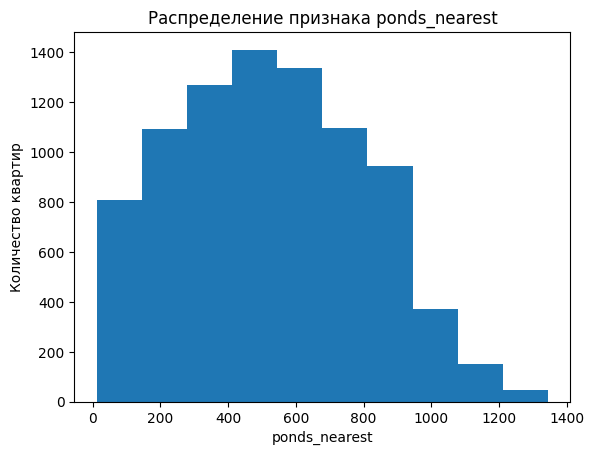

In [57]:
hist('ponds_nearest')

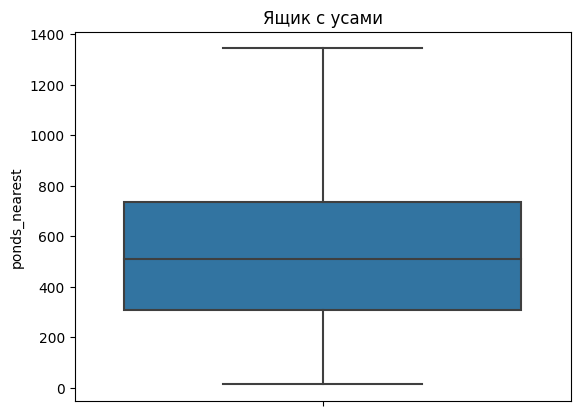

In [58]:
bxplt('ponds_nearest')

<div class="alert alert-info">
<b> Признаки airports_distance, centers_distance, parks_nearest, ponds_nearest распределены нормально с некоторыми сдвигами, однако так как в этих пропусках итак много пропущенных значений и расстояние до аэропорта центра парка и прудов может быть любым, поэтому из этих признаков ничего не удаляем)
<br>
</div>

<div class="alert alert-info">
<b> Вывод к Шагу 3: В ходе исследовательского анализа получено следующее -->
    
1) Убраны выбросы в признаках price, floors_total, rooms, ceiling_height
2) Проведен статистический анализ каждого из признаков

</div>

## Шаг 4. Добавление новых признаков, обоснование выбора

<div class="alert alert-info">
<b> Будут добавлены следующие признаки => 
    
1) тип этажа (первый, последний, промежуточный) ОБОСНОВАНИЕ: Ну вообще цена квартиры напрямую зависит от ее этажа, при этом стоимость квартир на первых и последних этажах обычно ниже, чем на средних, но в зависимости от типа дома (новостройка или вторичное жилье) есть нюансы. В новостройках верхние этажи могут быть дороже из-за панорамных видов и уникальных планировок, а на последнем этаже в старых домах цена ниже из-за потенциальных проблем с кровлей и отоплением.
2) Наличие балкона (0 и 1) ОБОСНОВАНИЕ: наличие балкона является важным критерием в выборе квартиры
3) Удаленность квартиры от центра города? (близко, средне, далеко). Ну тут думаю все итак понятно, цена квартиры напрямую зависит от того в центре или нет ее меcтоположение
4) Классификация зданий по этажности (на основе российских стандартов и источников):

Малоэтажные: до 2 этажей

Средней этажности: 3–5 этажей

Повышенной этажности: 6–9 этажей

Многоэтажные: 10–25 этажей

Высотные: более 25 этажей

</div>

In [59]:
def floor(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else: 
        return 'промежуточный'

In [60]:
data['type_of_floor'] = data.apply(floor, axis=1)

In [61]:
# data.head(10)

<div class="alert alert-info">
<b> Теперь у нас появился столбец с типом этажа, далее создадим столбец с информацией о наличии балкона в квартире

</div>

In [62]:
def balcony(row):
    if row['balcony'] == 0:
        return 0
    else:
        return 1

In [63]:
data['presence_of_a_balcony'] = data.apply(balcony, axis=1)

In [64]:
# data.head(10)

<div class="alert alert-info">
<b> Далее добим информацию о том насколько квартира отдалена от центра, выбрала медианное значение а не среднее, так как в данных есть выбросы)
</div>

In [65]:
median = data['centers_distance'].median()
def center(row):
    if row['centers_distance'] < median:
        return 'близко'
    elif row['centers_distance'] > median:
        return 'далеко'
    elif row['centers_distance'] == median:
        return 'средне'

In [66]:
data['location_from_the_center'] = data.apply(center, axis=1)

In [67]:
# data.head(10)

In [68]:
def type_of_building(row):
    if row['floors_total'] <= 2:
        return 'малоэтажка'
    elif row['floors_total'] >= 3 & row['floors_total'] <= 9:
        return 'среднеэтажка'
    elif row['floors_total'] >= 10 & row['floors_total'] <= 25:
        return 'многоэтажка'
    elif row['floors_total'] > 25:
        return 'высотка'

In [69]:
data['type_of_building'] = data.apply(type_of_building, axis=1)

In [70]:
# data.head(10)

<div class="alert alert-info">
<b> Вывод к Шагу 4: Итого в данном шаге были добавлены следующие признаки) -->
    
1) type_of_floor - тип этажа
2) presence_of_a_balcony - наличие балкаона
3) location_from_the_center - удаленность от центра
4) type_of_building - тип строения в котором находится квартира

</div>

## Шаг 5. Корреляционный анализ признаков

<div class="alert alert-info">
<b> Теперь посмотрим, как будут корреллировать м/у собой признаки и также проверим на мультиколлениарность.
Здесь будет применена phik для анализа и нелинейных зависимостей. Но для начала поменяем булевый тип признака studio на обычный int.
</div>

In [71]:
def studio(row):
    if row['studio'] == False:
        return 0
    else:
        return 1
data['studio'] = data.apply(studio, axis=1)

In [72]:
# data.head()

In [73]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['price', 'total_area', 'ceiling_height'
                 , 'ceiling_height', 'living_area', 'kitchen_area', 'airports_distance'
                , 'centers_distance', 'parks_nearest', 'ponds_nearest']

# считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(data, interval_cols=interval_cols)
print(phik_overview.shape) 

(18, 18)


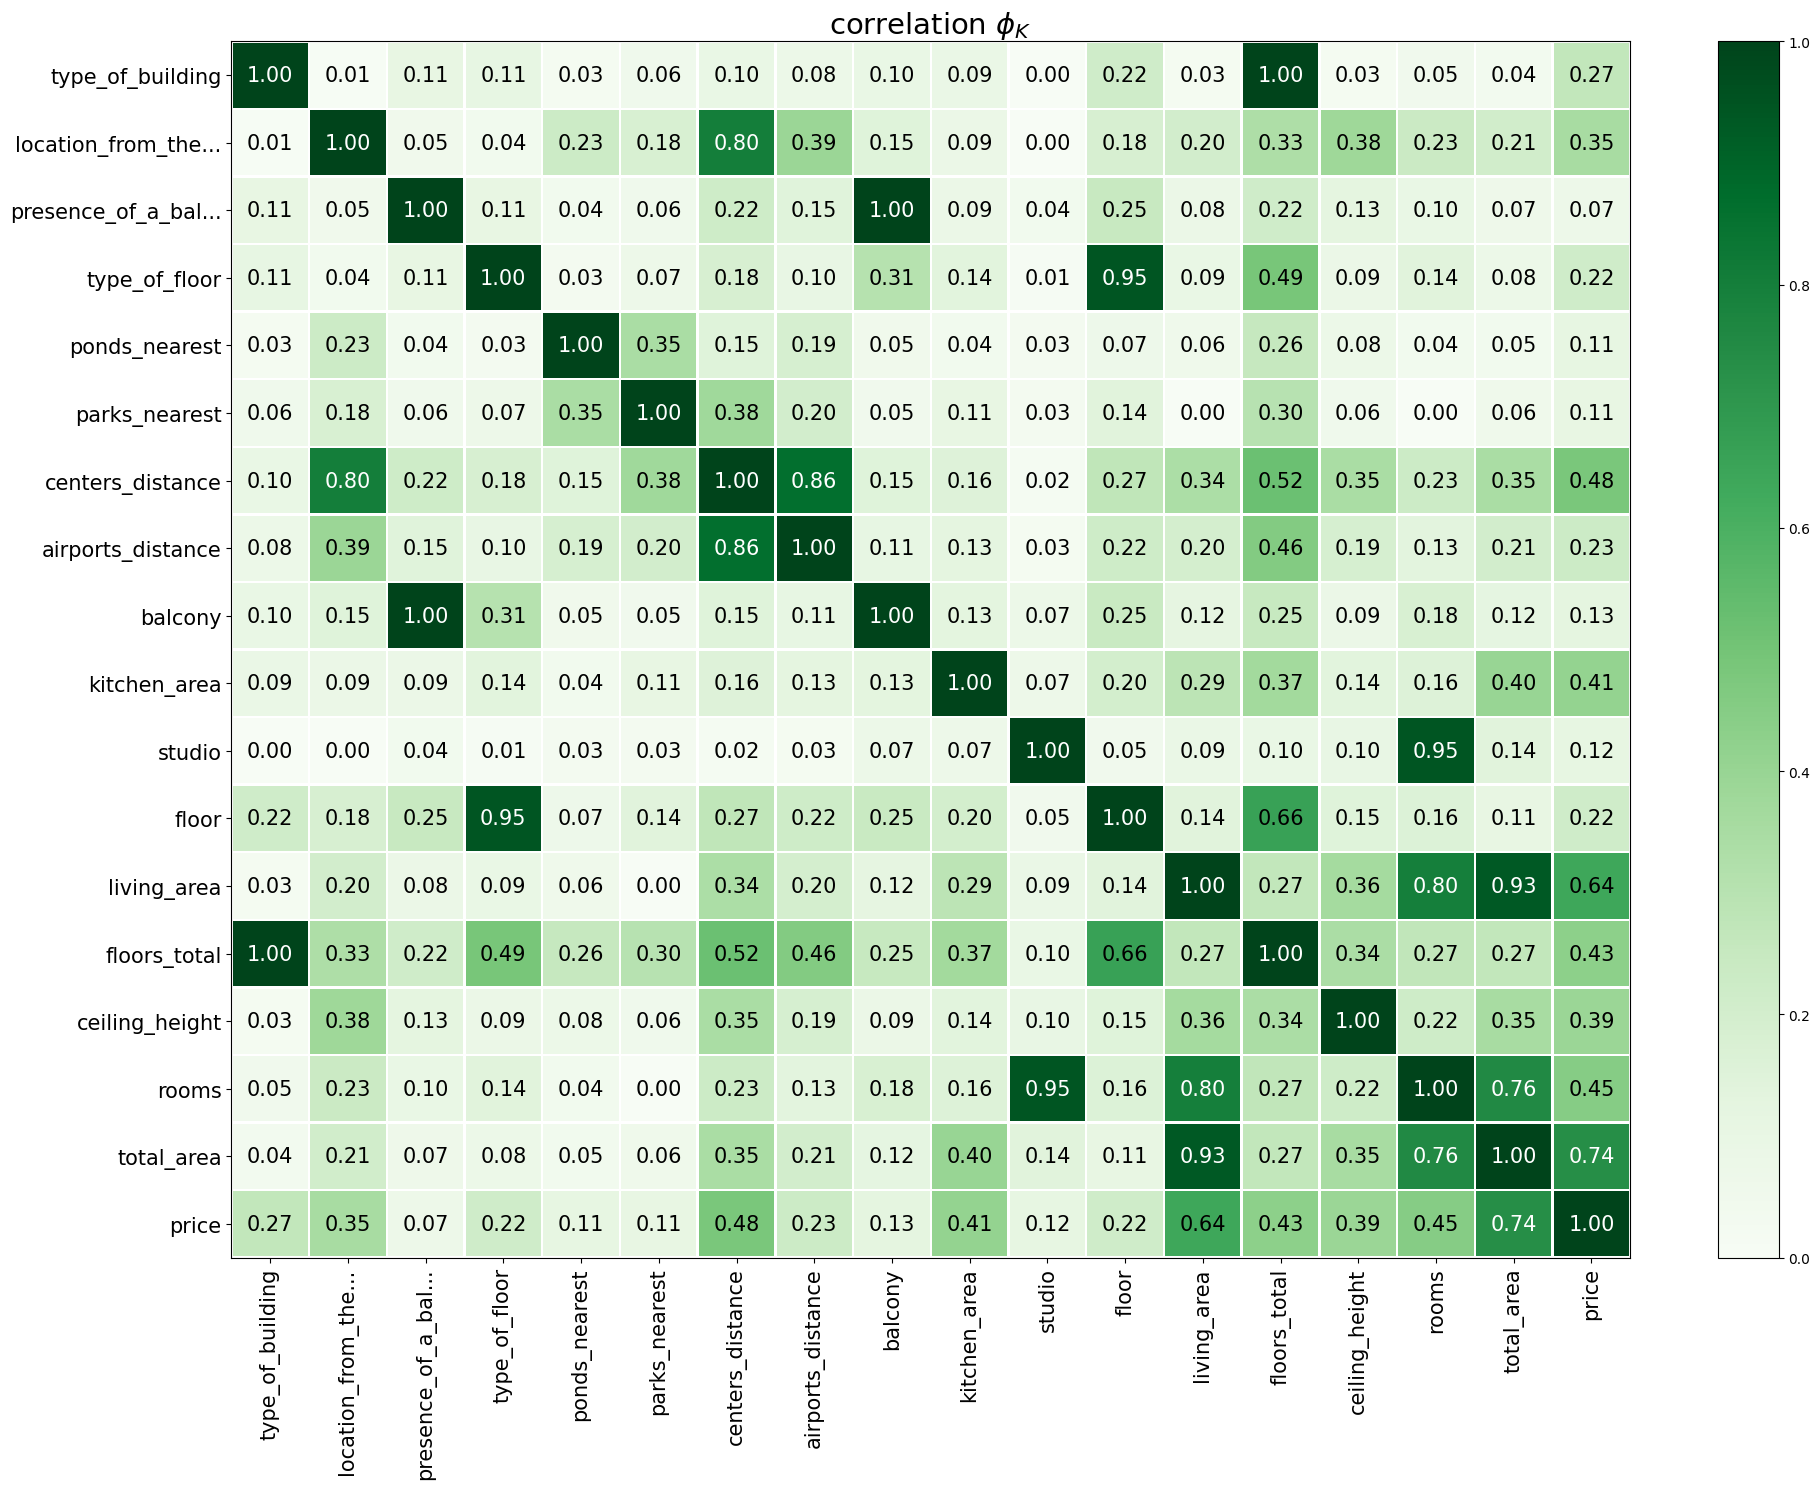

In [74]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div class="alert alert-info">
<b> В данных присутствует мультиколлениарность (0.90-0.95) и практически функциональная корреляция, это может плохо повлияеть на веса модели, так как по отдельности будет сложно оценить их вклад и влияние на целевой признак.
    
Утечки целевого признако НЕ ОБНАРУЖЕНО))
    
Итак, признаки location_from_the_center и centers_distance имеют сильную корреляцию, но не мульти-, поэтому оставляем пока как есть. Далее признаки type_of_floor и floor, очевидно что они будут мультиколлениарны, удаляем признак floor. Следующая пара - type_of_building и floors_total у них практически функциональная коллениарность поэтому убираем тот признак который меньше коррелирует с целевым - type_of_building (0.27 vs 0.43). Далее идут total_area и living_area, по той же логике удаляем living_area. rooms и studio - также удаляем studio(0.12). И последнее,  presence_of_a_balcony и balcony, удаляем presence_of_a_balcony
</div>

In [75]:
df = data.copy()
data = data.drop(['floor', 'type_of_building', 'living_area', 'studio', 'presence_of_a_balcony'], axis=1)

In [76]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['price', 'total_area', 'ceiling_height'
                 , 'ceiling_height', 'kitchen_area', 'airports_distance'
                , 'centers_distance', 'parks_nearest', 'ponds_nearest']

# считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(data, interval_cols=interval_cols)
print(phik_overview.shape) 

(13, 13)


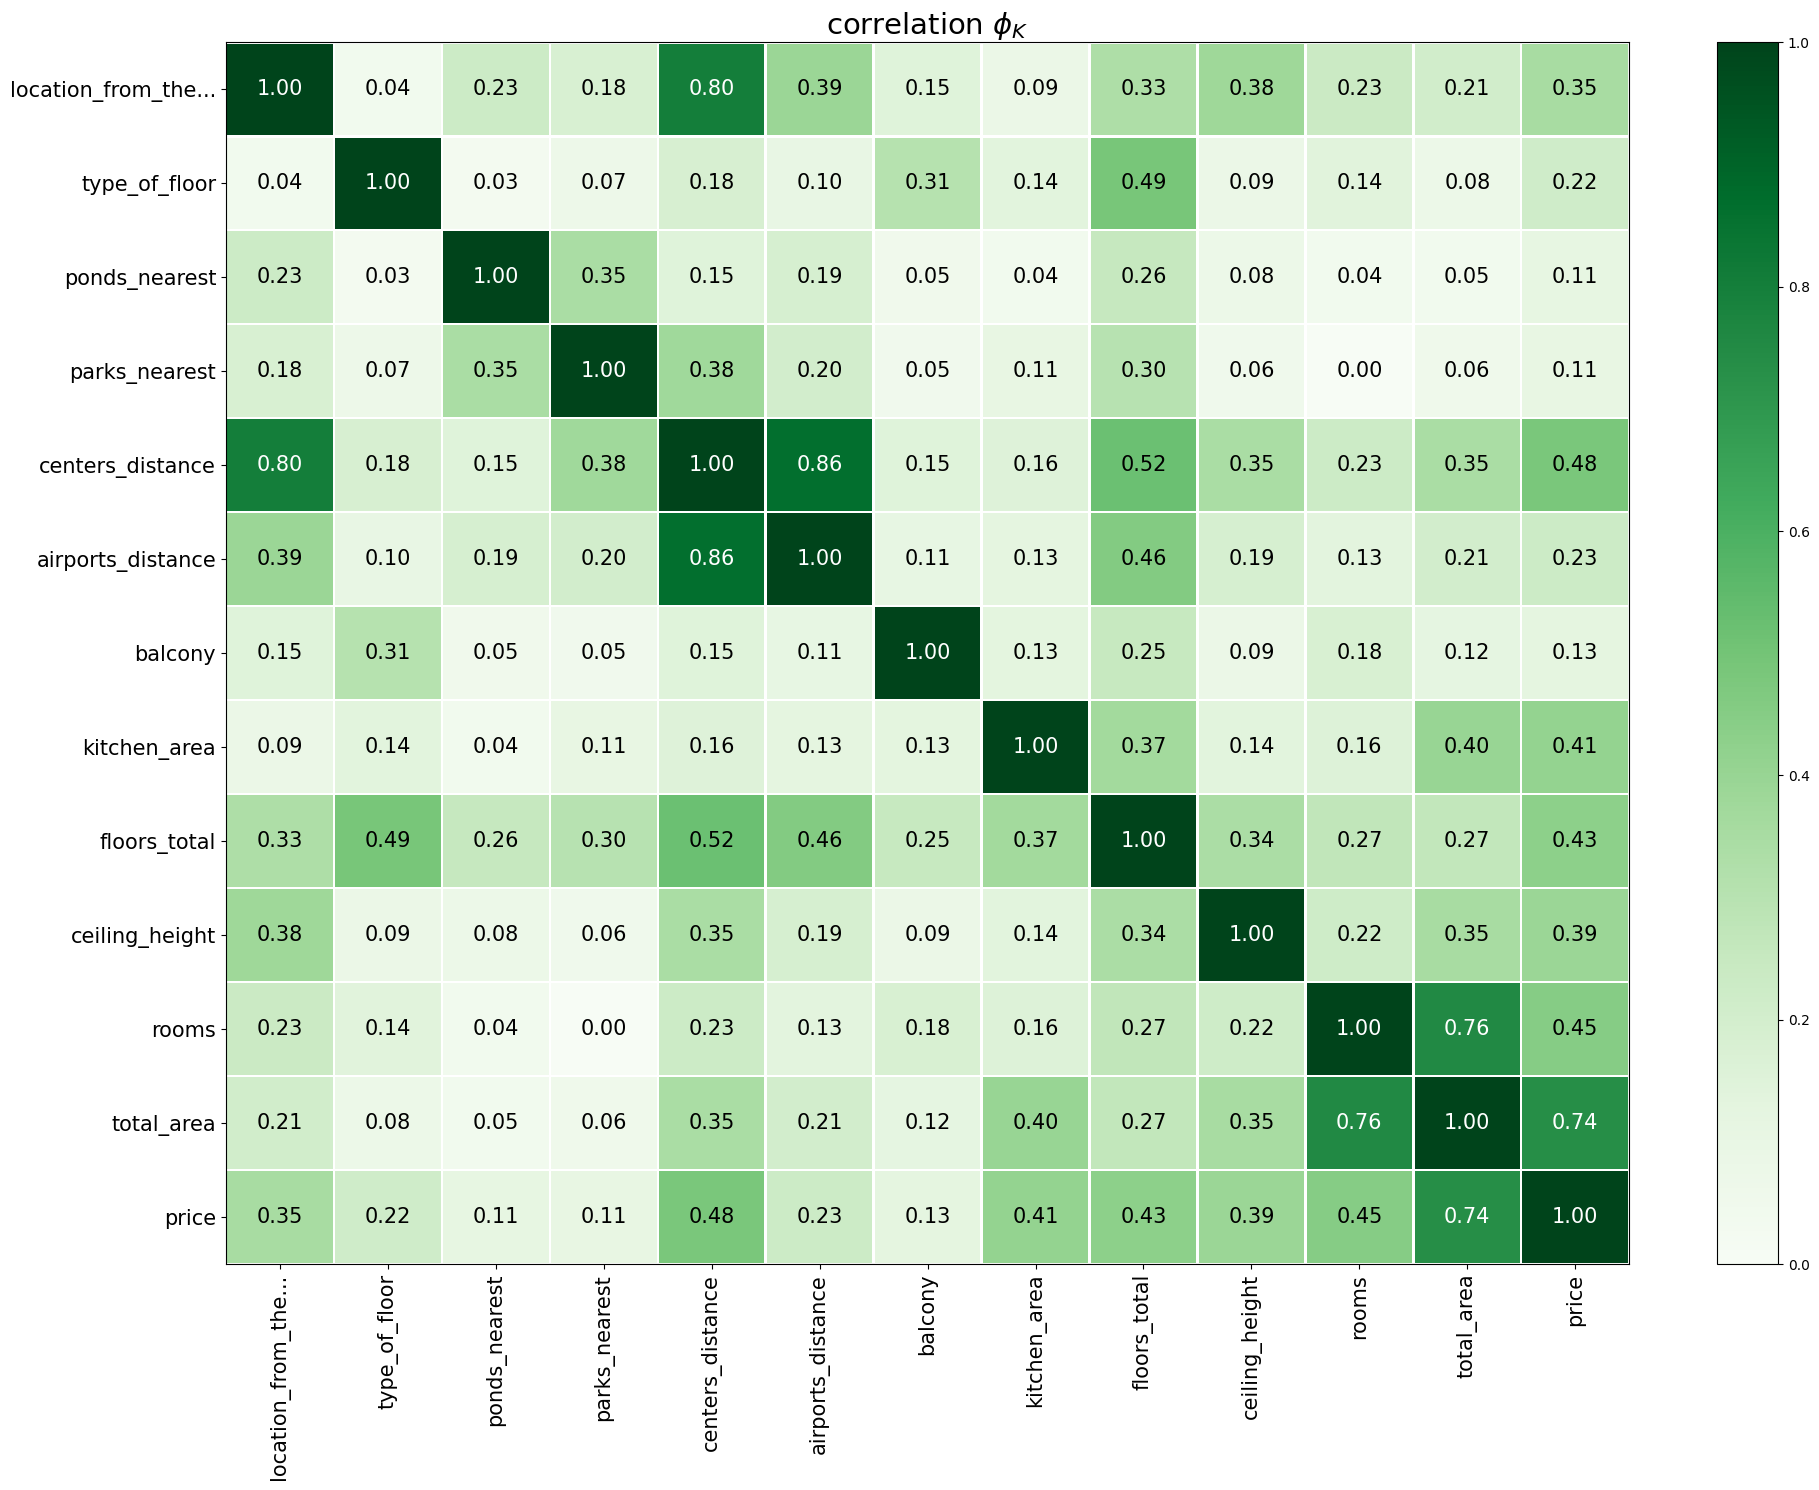

In [77]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div class="alert alert-info">
<b> Ну и славненько, с мультиколлениарностью разобрались)
</div>

<div class="alert alert-info">
<b> Вывод к шагу 5:
    
- Выявлена и устранена мультиколлениарность м/у признаками
    
- Утечки целевого признака не обнаружено
    
- Видно, что цена за квартиру зависит от таких признаков, как площадь всей квартиры, количества комнат и расстояния от центра, что очевидно, также влияние оказывает количество этажей в строении, высота потолков и площадь кухни)
    
</div>

## Шаг 6. Решение задачи регресии

<div class="alert alert-info">
<b> Для начала подготовим наши данные и разобьем на тестовые и тренировочные выборки)
При кодировании учитываем особенности признаков и модель выберем которая умеет работать с пропусками (lightGBM или CatBoost или XGBoost) и используем как минимум два кодировщика. Таким образом:
</div>

In [78]:
# data.shape

<div class="alert alert-info">
<b> Разделим данные на выборки)
</div>

In [79]:
X = data.drop('price', axis=1).reset_index(drop=True)
y = data['price'].reset_index(drop=True)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [81]:
# y_train

In [82]:
cat_columns = ['type_of_floor', 'location_from_the_center']
num_columns = ['total_area', 'rooms', 'ceiling_height'
           , 'floors_total', 'kitchen_area', 'balcony', 'airports_distance'
           , 'centers_distance', 'parks_nearest', 'ponds_nearest']

<div class="alert alert-info">
<b> Собираем пайплайн
</div>

In [83]:
cat_pipe = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [84]:
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_columns),
    ('num', 'passthrough', num_columns)
], remainder='drop')

In [85]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=RANDOM_STATE))
])

In [86]:
param_grid = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [10, 15],
    'model__num_leaves': [31, 50],
    'model__n_estimators': [500, 900],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0], 
    'model__verbose': [-1] # добавила чтобы лог не засорять  
}

search = GridSearchCV( # выбрала именно по сетке потому что он перебирает все возможные комбинации параметров,
    # да долго но зато надежно)
    pipe,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

<div class="alert alert-info">
<b> Теперь можно и поучить модельку)
</div>

In [87]:
print("****************************** Обучение LightGBM ***********************************")
search.fit(X_train, y_train)

print("\nЛучшие параметры:", search.best_params_)
print("Лучший R² на кросс-валидации:", round(search.best_score_, 4))

****************************** Обучение LightGBM ***********************************
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Лучшие параметры: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 15, 'model__n_estimators': 500, 'model__num_leaves': 50, 'model__subsample': 0.8, 'model__verbose': -1}
Лучший R² на кросс-валидации: 0.8482


<div class="alert alert-info">
<b> И оценим точность модели на тестовой выборки
</div>

In [88]:
y_pred = search.predict(X_test)

print(f"\n Метрики на тестовой выборке:")

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")


 Метрики на тестовой выборке:
R²: 0.8448
MAE: 764068.46
RMSE: 1237392.24


<div class="alert alert-info">
<b> Вывод к шагу 6: 
    
Итак, на тестовой выборке коэффициент детерминации оказался равен 0.84, что является приемлемым результатом, в открытых источниках и на основе моего опыта можно сказать, что модель объясняет большую часть дисперсии, но есть заметные ошибки, что является хорошим качеством интерпретации.

Что касается MAE и RMSE, видно, что в среднем модель ошибается на ~ 760 тыс. рублей, а среднеквадратичное отклонение ~1.24 млн. ОДНАКО 84% дисперсии цены ОБЪЯСНЯЮТСЯ МОДЕЛЬЮ/
</div>

## Шаг 7. Общие выводы

<div class="alert alert-info">
<b> Для начала посмотрим на важность признаков)
</div>

In [89]:
best_model = search.best_estimator_.named_steps['model']
feature_names = cat_columns + num_columns

feature_importances = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importances.head(10))


Топ-10 важных признаков:
total_area           4041
centers_distance     3908
airports_distance    3333
kitchen_area         3181
ponds_nearest        2416
parks_nearest        2302
floors_total         1889
ceiling_height       1609
rooms                 816
balcony               448
dtype: int32


In [90]:
explainer = shap.Explainer(best_model)
X_test_transformed = search.best_estimator_.named_steps['preprocessor'].transform(X_test)
shap_values = explainer(X_test_transformed)

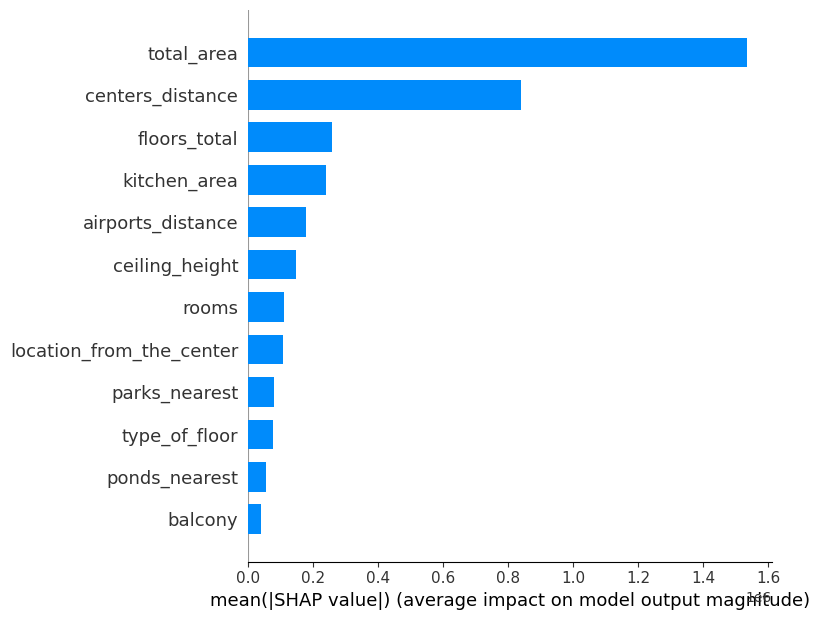

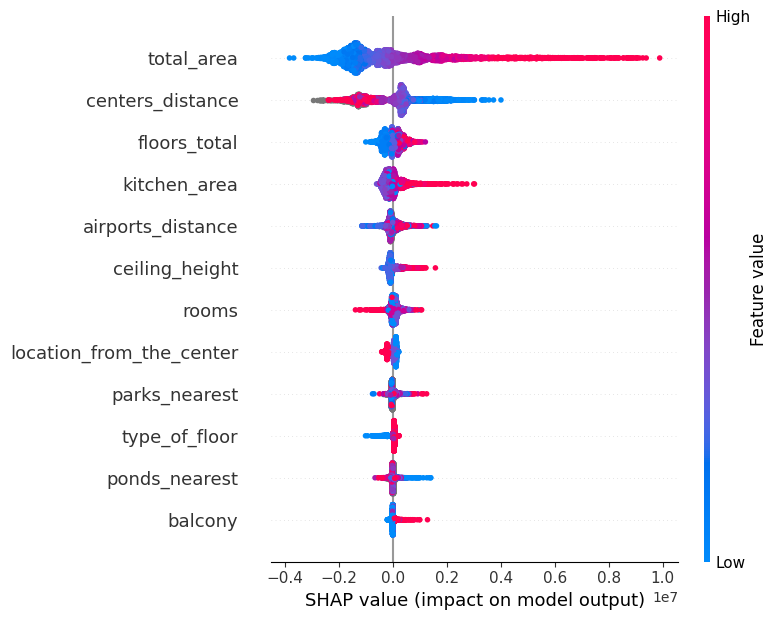

In [91]:
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names)

<div class="alert alert-info">
<b> Ну впринципе ожидаемо, 

площадь квартиры сильно влияет на предсказанную цену, с ростом площади цена увеличивается и наоборот

так видно, что чем меньше расстояние от квартиры до центра, тем больше предсказанная цена квартиры

наличие пруда поблизости и количество балконов вносят малый вклад в предсказоваемое ценообразование квариры

Интересно, что почему то в некоторых случаях увеличение комнат в квартире уменьшает ее предсказанную цену 
</div>

<div class="alert alert-info">
<b> Теперь и какую нибудь гипотезу можно проверить) Вот к примеру хочу проверить, что цена на первом этаже у квартир будет ниже)
</div>

<div class="alert alert-info">
<b> Нулевая гипотеза (H₀) - Цена квартиры на первом этаже не отличается от цены квартир на других этажах.

Альтернативная гипотеза (H₁) - Цена квартиры на первом этаже ниже, чем на остальных этажах.
</div>

In [92]:
first_floor = df[df['floor'] == 1]
another_floor = df[df['floor'] != 1]

first_floor = first_floor[first_floor['price'] <= 20000000]
another_floor = another_floor[another_floor['price'] <= 20000000]

In [93]:
# first_floor

In [94]:
# another_floor

In [95]:
alpha = 0.05 
results = st.ttest_ind(first_floor['price'], another_floor['price'], alternative = 'less')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 9.08448695927503e-77
Отвергаем нулевую гипотезу


<div class="alert alert-info">
<b> Значение p-value почти равное нулю) и следовательно --> Есть статистически значимое подтверждение того, что квартиры на первом этаже дешевле, чем на других этажах.
</div>

<div class="alert alert-info">
<b> Теперь посмотрим как различные группы в признаках влияют на цену квартиры)
</div>

In [96]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

df['room_group'] = pd.cut(df['rooms'], bins=[0,1,2,100], labels=['1-комн','2-комн','3+'])
df['floor_group'] = pd.cut(df['floors_total'], bins=[0,5,12,100], labels=['низкие','средние','высокие'])
df['studio_group'] = df['studio'].apply(lambda x: 'студия' if x else 'не студия')

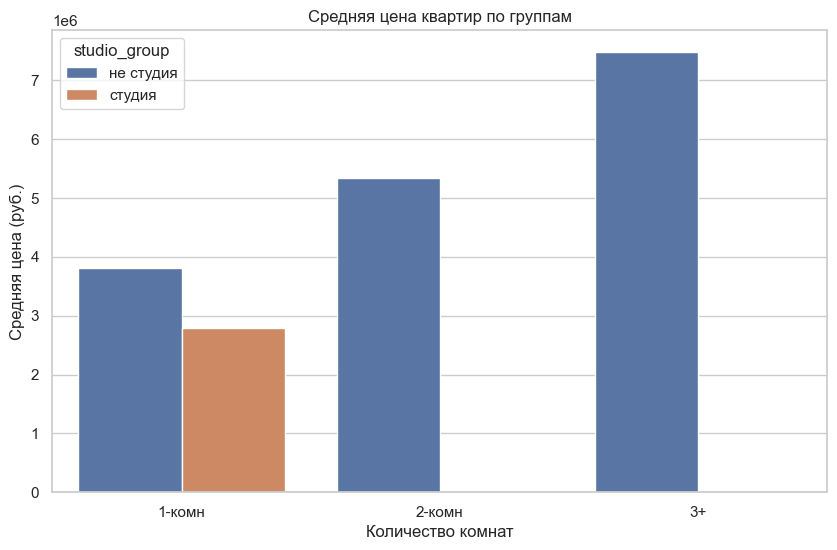

In [97]:
price_group = df.groupby(['room_group','studio_group'])['price'].mean().reset_index()

sns.barplot(x='room_group', y='price', hue='studio_group', data=price_group)
plt.title('Средняя цена квартир по группам')
plt.ylabel('Средняя цена (руб.)')
plt.xlabel('Количество комнат')
plt.show()

<div class="alert alert-info">
<b> Средняя цена у кввартир студий ниже чем у однокомнатных, цена растет с ростом количества комнат, то есть чем больше комнат тем больше цена)
</div>

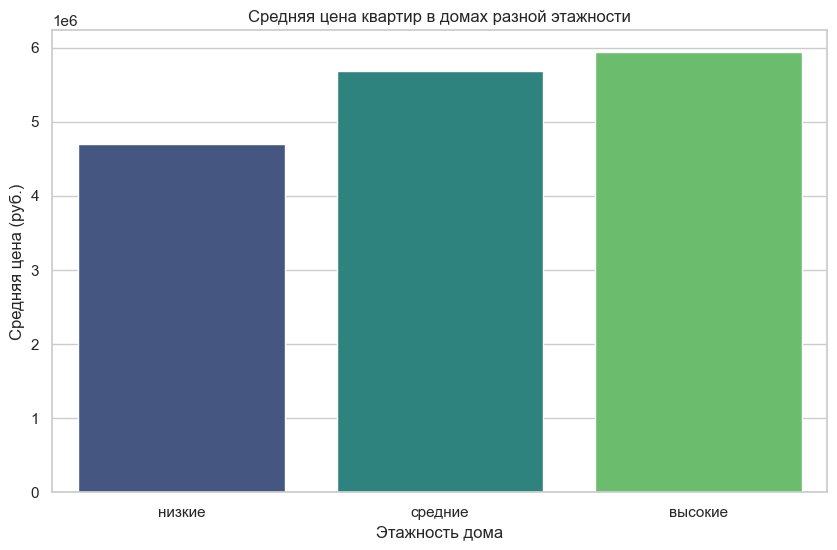

In [98]:
floor_price = df.groupby('floor_group')['price'].mean().reset_index()

sns.barplot(x='floor_group', y='price', data=floor_price, palette='viridis')
plt.title('Средняя цена квартир в домах разной этажности')
plt.xlabel('Этажность дома')
plt.ylabel('Средняя цена (руб.)')
plt.show()


<div class="alert alert-info">
<b> Тут тоже видим, что чем больше этажей в постройке, тем дороже квартиры. Чем ниже эатж, теи дешевле квартира)
</div>

## ОБЩИЙ ВЫВОД:
ПОДВЕДЕМ ИТОГИ...
В ходе данной работы были проделаны следующие шаги с соответствующими результатами:

- Шаг 1 -  было обнаружено, что в данных есть пропуски и их довольно много, в данных есть выбросы и/или аномалии, Некоторые типы данных нужно было поменять
- Шаг 2 - проведена предобработка данных, удалено большее количсевто пропусков и изменены типы данных 
- Шаг 3 - Проведен Исследовательский/Cтатистический анализ данных - были удалены выбросы и аномалии в признаках
- Шаг 4 - были добавлены следующие признаки: type_of_floor - тип этажа, presence_of_a_balcony - наличие балкаона, location_from_the_center - удаленность от центра, type_of_building - тип строения в котором находится квартира
- Шаг 5 - проведен корреляционный анализ - Выявлена и устранена мультиколлениарность м/у признаками, Утечки целевого признака не обнаружено, сделан вывод о том, что цена за квартиру зависит от таких признаков, как площадь всей квартиры, количества комнат и расстояния от центра, что очевидно, также влияние оказывает количество этажей в строении, высота потолков и площадь кухни)
- Шаг 6 - Подобрана и обучена модель регрессии LightGBM - на тестовой выборке коэффициент детерминации оказался равен 0.84, что является приемлемым результатом, в открытых источниках и на основе моего опыта можно сказать, что модель объясняет большую часть дисперсии, но есть заметные ошибки, что является хорошим качеством интерпретации. Что касается MAE и RMSE, видно, что в среднем модель ошибается на ~ 760 тыс. рублей, а среднеквадратичное отклонение ~1.24 млн. ОДНАКО 84% дисперсии цены ОБЪЯСНЯЮТСЯ МОДЕЛЬЮ.

    Таким образом УДАЛОСЬ предсказать стоимость квартир в городе N, с помощью обученного алгоритма LightGBM с точностью 84%

    Также в ходе работы было статистически доказано, что цены квартир на первых этажа ниже, чем на других. А Средняя цена у квартир студий ниже, чем у однокомнатных и цена растет с ростом количества комнат, то есть чем больше комнат тем больше цена). И что, чем больше этажей в постройке, тем дороже квартиры.

Работа выполнена Гареевой Д.Р (507540), j4150